In [1]:
from pathlib import Path

DATA_DIR = Path("../data/brain-tumor-mri-dataset")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())


Dataset exists: True
Dataset path: C:\Users\karyl\projects\brain-mri\data\brain-tumor-mri-dataset


In [2]:
print("Folders in dataset:")

for folder in DATA_DIR.iterdir():
    print("-", folder.name)

Folders in dataset:
- Testing
- Training


In [3]:
for split in ["Training", "Testing"]:

    split_dir = DATA_DIR / split

    print(f"\n{split}:")

    for class_dir in split_dir.iterdir():
        print("-", class_dir.name)


Training:
- glioma
- meningioma
- notumor
- pituitary

Testing:
- glioma
- meningioma
- notumor
- pituitary


In [4]:
for split in ["Training", "Testing"]:
    split_dir = DATA_DIR / split

    print(f"\n{split}:")

    for class_dir in split_dir.iterdir():
        images = list(class_dir.iterdir())
        print(f"- {class_dir.name}: {len(images)} images")


Training:
- glioma: 1400 images
- meningioma: 1400 images
- notumor: 1400 images
- pituitary: 1400 images

Testing:
- glioma: 400 images
- meningioma: 400 images
- notumor: 400 images
- pituitary: 400 images


In [5]:
for class_name in ["glioma", "meningioma", "notumor", "pituitary"]:
    class_dir = DATA_DIR / "Training" / class_name

    first_image = next(class_dir.iterdir())

    print(class_name, "->", first_image.name)


glioma -> Tr-gl_1.jpg
meningioma -> Tr-aug-me_1.jpg
notumor -> Tr-no_1.jpg
pituitary -> Tr-pi_1.jpg


In [11]:
import cv2

image_path = DATA_DIR / "Training" / "glioma" / "Tr-gl_1.jpg"

image = cv2.imread(str(image_path))

print(image)
print("Share:", image.shape)
print("Data type:", image.dtype)



[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]
Share: (512, 512, 3)
Data type: uint8


In [12]:
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())
print("Average pixel value:", image.mean())

Minimum pixel value: 0
Maximum pixel value: 255
Average pixel value: 34.5438232421875


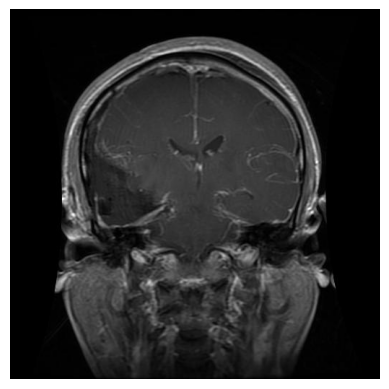

In [14]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

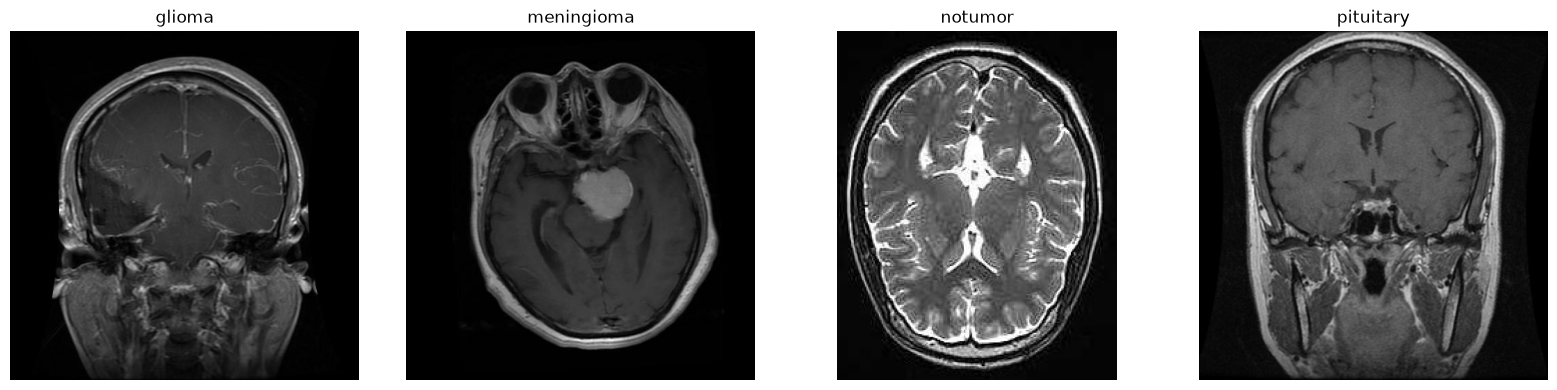

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, class_name in enumerate(["glioma", "meningioma", "notumor", "pituitary"]):
    class_dir = DATA_DIR / "Training" / class_name
    image_path = next(class_dir.iterdir())

    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[i].imshow(image_rgb)
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
from collections import Counter

shape_counts = Counter()

for split in ["Training", "Testing"]:
    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():
        for image_path in class_dir.iterdir():
            image = cv2.imread(str(image_path))

            if image is not None:
                shape_counts[image.shape] += 1

print("Unique image shapes:", len(shape_counts))

for shape, count in shape_counts.most_common():
    print(shape, "->", count)

Unique image shapes: 447
(512, 512, 3) -> 5014
(225, 225, 3) -> 338
(630, 630, 3) -> 90
(251, 201, 3) -> 57
(221, 228, 3) -> 51
(217, 232, 3) -> 50
(442, 442, 3) -> 48
(236, 236, 3) -> 48
(198, 150, 3) -> 44
(252, 200, 3) -> 43
(417, 428, 3) -> 42
(222, 227, 3) -> 39
(201, 173, 3) -> 36
(244, 206, 3) -> 35
(256, 256, 3) -> 33
(192, 192, 3) -> 31
(250, 201, 3) -> 29
(231, 218, 3) -> 29
(234, 215, 3) -> 28
(262, 227, 3) -> 27
(444, 468, 3) -> 24
(242, 208, 3) -> 24
(540, 504, 3) -> 23
(449, 359, 3) -> 23
(236, 214, 3) -> 22
(168, 300, 3) -> 21
(442, 400, 3) -> 20
(213, 236, 3) -> 19
(400, 393, 3) -> 18
(243, 207, 3) -> 18
(454, 442, 3) -> 17
(282, 230, 3) -> 17
(326, 276, 3) -> 17
(442, 441, 3) -> 16
(214, 235, 3) -> 16
(664, 550, 3) -> 16
(259, 194, 3) -> 15
(680, 680, 3) -> 15
(280, 420, 3) -> 14
(340, 339, 3) -> 13
(238, 212, 3) -> 12
(183, 275, 3) -> 12
(361, 642, 3) -> 12
(257, 196, 3) -> 12
(530, 380, 3) -> 12
(350, 350, 3) -> 11
(197, 177, 3) -> 9
(474, 356, 3) -> 9
(393, 350, 3) 

In [17]:
extension_counts = Counter()

for split in ["Training", "Testing"]:
    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():
        for image_path in class_dir.iterdir():
            extension_counts[image_path.suffix.lower()] += 1

print(extension_counts)

Counter({'.jpg': 7200})


In [20]:
for split in ["Training", "Testing"]:
    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():
        for image_path in class_dir.iterdir():
            image = cv2.imread(str(image_path))

            if image is not None and image.shape[:2] != (512, 512):
                print("Found:", image_path)
                print("Original shape:", image.shape)
                break

Found: ..\data\brain-tumor-mri-dataset\Training\meningioma\Tr-me_1014.jpg
Original shape: (212, 226, 3)
Found: ..\data\brain-tumor-mri-dataset\Training\notumor\Tr-no_1.jpg
Original shape: (251, 201, 3)
Found: ..\data\brain-tumor-mri-dataset\Training\pituitary\Tr-pi_1029.jpg
Original shape: (741, 900, 3)
Found: ..\data\brain-tumor-mri-dataset\Testing\glioma\Te-gl_1.jpg
Original shape: (442, 354, 3)
Found: ..\data\brain-tumor-mri-dataset\Testing\meningioma\Te-me_1.jpg
Original shape: (442, 442, 3)
Found: ..\data\brain-tumor-mri-dataset\Testing\notumor\Te-no_1.jpg
Original shape: (252, 200, 3)
Found: ..\data\brain-tumor-mri-dataset\Testing\pituitary\Te-pi_104.jpg
Original shape: (256, 256, 3)


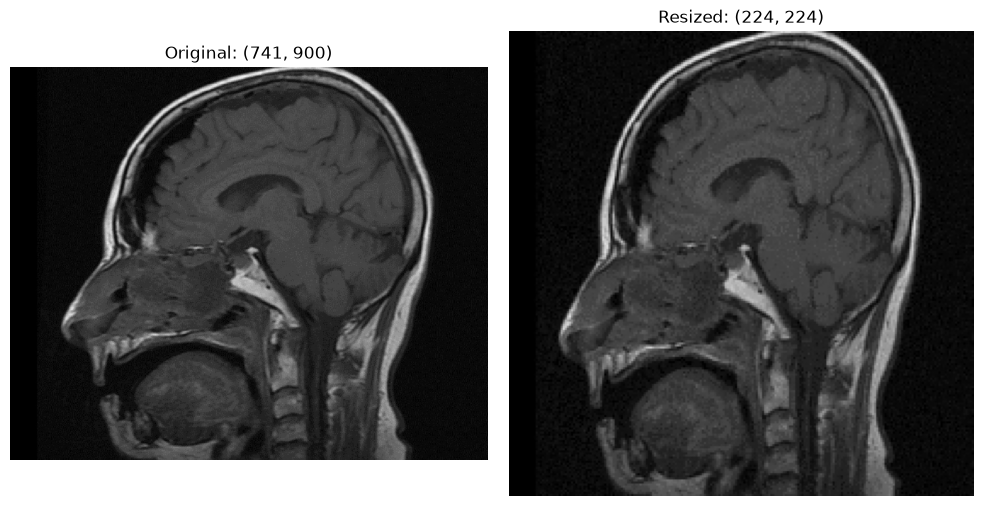

In [21]:
image_path = DATA_DIR / "Training" / "pituitary" / "Tr-pi_1029.jpg"

image = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

resized = cv2.resize(image_rgb, (224, 224))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image_rgb)
axes[0].set_title(f"Original: {image_rgb.shape[:2]}")
axes[0].axis("off")

axes[1].imshow(resized)
axes[1].set_title(f"Resized: {resized.shape[:2]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [23]:
#meh
import numpy as np

image_path = DATA_DIR / "Training" / "pituitary" / "Tr-pi_1029.jpg"

image = cv2.imread(str(image_path))

blue = image[:, :, 0]
green = image[:, :, 1]
red = image[:, :, 2]

print("Blue == Green:", np.array_equal(blue, green))
print("Green == Red:", np.array_equal(green, red))
print("Blue == Red:", np.array_equal(blue, red))

Blue == Green: True
Green == Red: True
Blue == Red: True


In [24]:
for class_name in ["glioma", "meningioma", "notumor", "pituitary"]:
    class_dir = DATA_DIR / "Training" / class_name
    image_path = next(class_dir.iterdir())

    image = cv2.imread(str(image_path))

    same_channels = (
        np.array_equal(image[:, :, 0], image[:, :, 1])
        and
        np.array_equal(image[:, :, 1], image[:, :, 2])
    )

    print(f"{class_name}: {same_channels}")

glioma: True
meningioma: True
notumor: True
pituitary: True


In [25]:
heights = []
widths = []

for split in ["Training", "Testing"]:
    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():
        for image_path in class_dir.iterdir():
            image = cv2.imread(str(image_path))

            if image is not None:
                height, width = image.shape[:2]
                heights.append(height)
                widths.append(width)

print("Height:")
print("  Minimum:", min(heights))
print("  Maximum:", max(heights))
print("  Average:", sum(heights) / len(heights))
print("  Median:", np.median(heights))

print("\nWidth:")
print("  Minimum:", min(widths))
print("  Maximum:", max(widths))
print("  Average:", sum(widths) / len(widths))
print("  Median:", np.median(widths))

Height:
  Minimum: 167
  Maximum: 1446
  Average: 456.89916666666664
  Median: 512.0

Width:
  Minimum: 150
  Maximum: 1375
  Average: 453.30291666666665
  Median: 512.0


In [26]:
#resizing all images to 512 x 512 x 3 makes sense now but it needs too much more computation and memory so i'll stick with 224 x 224 x3

aspect_ratios = []

for split in ["Training", "Testing"]:
    split_dir = DATA_DIR / split

    for class_dir in split_dir.iterdir():
        for image_path in class_dir.iterdir():
            image = cv2.imread(str(image_path))

            if image is not None:
                height, width = image.shape[:2]
                aspect_ratios.append(width / height)

print("Minimum aspect ratio:", min(aspect_ratios))
print("Maximum aspect ratio:", max(aspect_ratios))
print("Average aspect ratio:", sum(aspect_ratios) / len(aspect_ratios))
print("Median aspect ratio:", np.median(aspect_ratios))

Minimum aspect ratio: 0.644808743169399
Maximum aspect ratio: 1.7857142857142858
Average aspect ratio: 0.9896993859533322
Median aspect ratio: 1.0


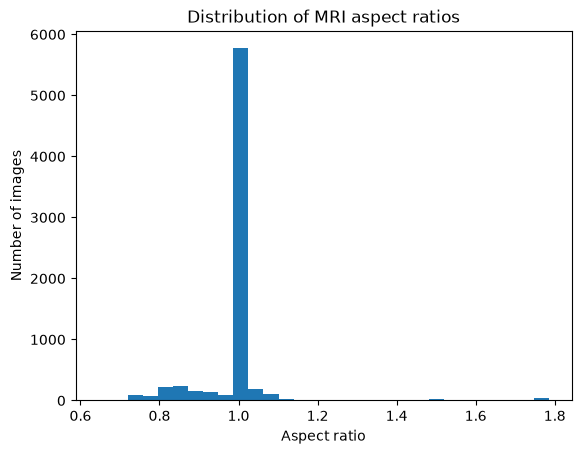

In [27]:
plt.hist(aspect_ratios, bins=30)

plt.xlabel("Aspect ratio")
plt.ylabel("Number of images")
plt.title("Distribution of MRI aspect ratios")

plt.show()


In [28]:
for class_name in ["glioma", "meningioma", "notumor", "pituitary"]:
    class_dir = DATA_DIR / "Training" / class_name
    image_path = next(class_dir.iterdir())

    image = cv2.imread(str(image_path))

    print(class_name)
    print("Top-left:", image[0, 0])
    print("Top-right:", image[0, -1])
    print("Bottom-left:", image[-1, 0])
    print("Bottom-right:", image[-1, -1])
    print()

glioma
Top-left: [0 0 0]
Top-right: [0 0 0]
Bottom-left: [0 0 0]
Bottom-right: [0 0 0]

meningioma
Top-left: [0 0 0]
Top-right: [0 0 0]
Bottom-left: [0 0 0]
Bottom-right: [0 0 0]

notumor
Top-left: [3 3 3]
Top-right: [3 3 3]
Bottom-left: [3 3 3]
Bottom-right: [5 5 5]

pituitary
Top-left: [0 0 0]
Top-right: [0 0 0]
Bottom-left: [1 1 1]
Bottom-right: [1 1 1]



In [30]:
import cv2
import numpy as np

IMG_SIZE = 224

def resize_with_padding(image, target_size=IMG_SIZE):
    height, width = image.shape[:2]

    scale = min(target_size / width, target_size / height)

    new_width = int(width * scale)
    new_height = int(height * scale)

    resized = cv2.resize(image, (new_width, new_height))

    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    x_offset = (target_size - new_width) // 2
    y_offset = (target_size - new_height) // 2

    canvas[
        y_offset:y_offset + new_height,
        x_offset:x_offset + new_width
    ] = resized

    return canvas

In [31]:
image_path = DATA_DIR / "Training" / "pituitary" / "Tr-pi_1029.jpg"

image = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

processed = resize_with_padding(image_rgb)

print("Original:", image_rgb.shape)
print("Processed:", processed.shape)

Original: (741, 900, 3)
Processed: (224, 224, 3)


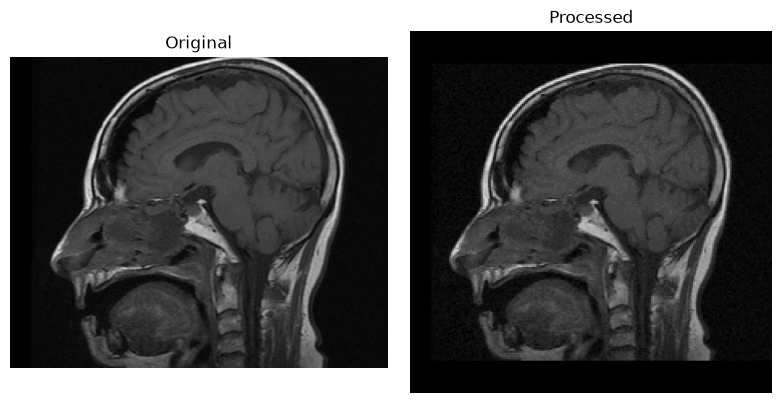

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(processed)
axes[1].set_title("Processed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [33]:
normalized = processed.astype(np.float32) / 255.0

print("Before:")
print("dtype:", processed.dtype)
print("min:", processed.min())
print("max:", processed.max())

print("\nAfter:")
print("dtype:", normalized.dtype)
print("min:", normalized.min())
print("max:", normalized.max())

Before:
dtype: uint8
min: 0
max: 241

After:
dtype: float32
min: 0.0
max: 0.94509804


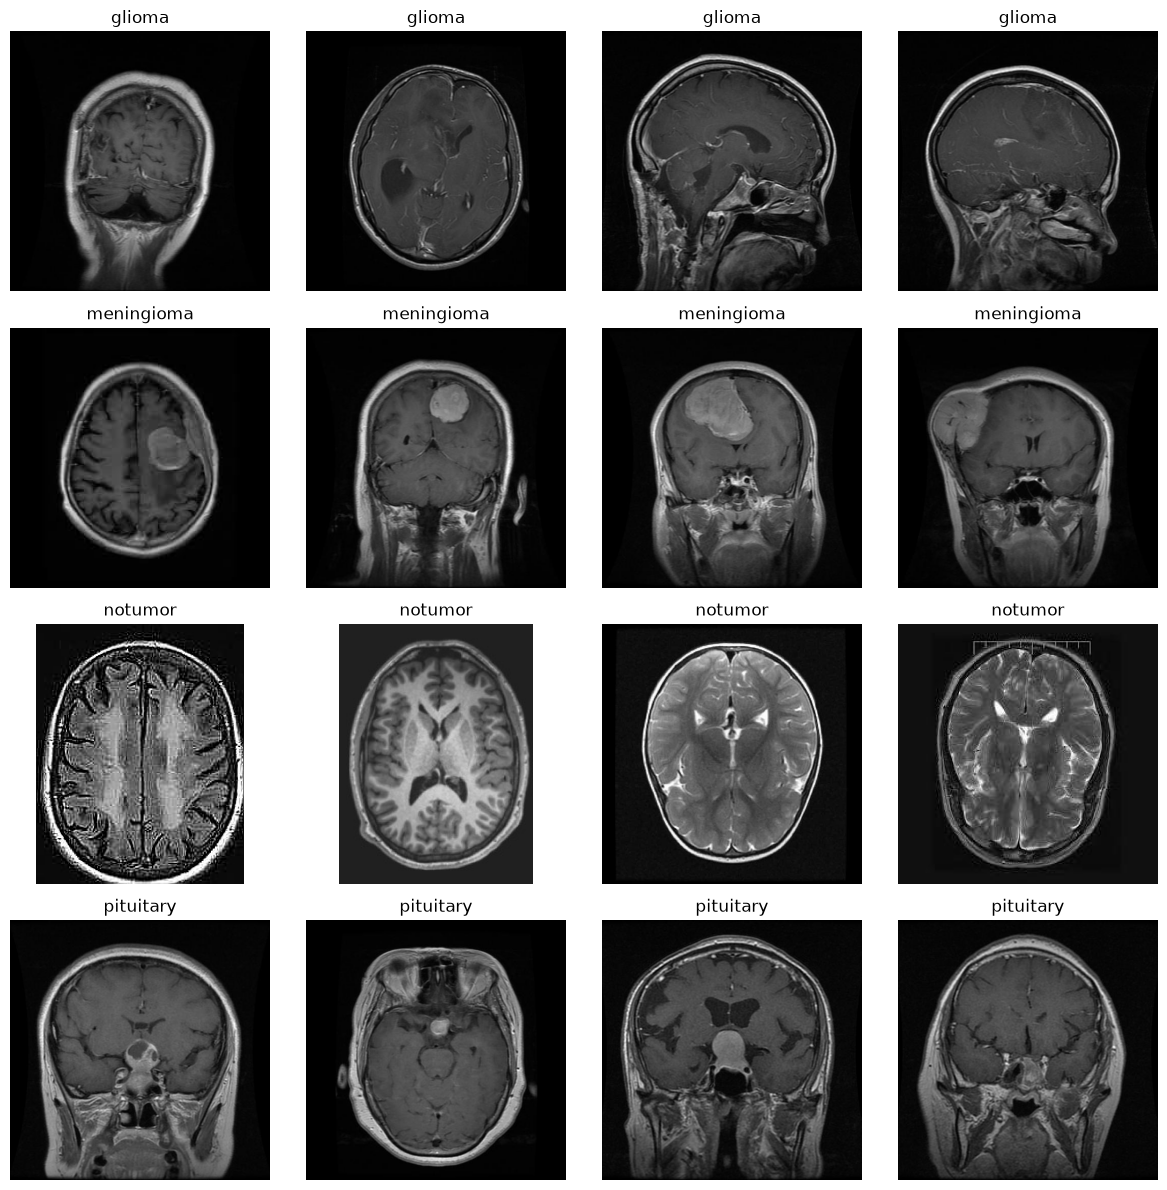

In [34]:
import random

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, class_name in enumerate(class_names):
    class_dir = DATA_DIR / "Training" / class_name
    image_paths = list(class_dir.iterdir())
    
    random_images = random.sample(image_paths, 4)

    for col, image_path in enumerate(random_images):
        image = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image_rgb)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [35]:
class_name = "glioma"

class_dir = DATA_DIR / "Training" / class_name
image_path = next(class_dir.iterdir())

image = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

processed = resize_with_padding(image_rgb)
normalized = processed.astype(np.float32) / 255.0

label = 0

print("Image shape:", normalized.shape)
print("Image dtype:", normalized.dtype)
print("Pixel range:", normalized.min(), "to", normalized.max())
print("Label:", label)
print("Class:", class_name)

Image shape: (224, 224, 3)
Image dtype: float32
Pixel range: 0.0 to 0.96862745
Label: 0
Class: glioma


In [36]:
def preprocess_image(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    processed = resize_with_padding(image_rgb)

    normalized = processed.astype(np.float32) / 255.0

    return normalized

In [37]:
image_path = DATA_DIR / "Training" / "glioma" / "Tr-gl_1.jpg"

processed_image = preprocess_image(image_path)

print("Shape:", processed_image.shape)
print("Dtype:", processed_image.dtype)
print("Min:", processed_image.min())
print("Max:", processed_image.max())

Shape: (224, 224, 3)
Dtype: float32
Min: 0.0
Max: 0.96862745


In [38]:
class_to_label = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

print(class_to_label)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [39]:
class_name = "meningioma"

class_dir = DATA_DIR / "Training" / class_name
image_path = next(class_dir.iterdir())

processed_image = preprocess_image(image_path)
label = class_to_label[class_name]

print("Image:", image_path.name)
print("Shape:", processed_image.shape)
print("Label:", label)
print("Class:", class_name)

Image: Tr-aug-me_1.jpg
Shape: (224, 224, 3)
Label: 1
Class: meningioma


In [40]:
X_train = []
y_train = []

for class_name, label in class_to_label.items():
    class_dir = DATA_DIR / "Training" / class_name

    for image_path in class_dir.iterdir():
        image = preprocess_image(image_path)

        if image is not None:
            X_train.append(image)
            y_train.append(label)

print("Images:", len(X_train))
print("Labels:", len(y_train))

Images: 5600
Labels: 5600


In [41]:
X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (5600, 224, 224, 3)
y_train shape: (5600,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Training: (4480, 224, 224, 3) (4480,)
Validation: (1120, 224, 224, 3) (1120,)


In [43]:
print("Training class distribution:")
print(np.unique(y_train, return_counts=True))

print("\nValidation class distribution:")
print(np.unique(y_val, return_counts=True))

Training class distribution:
(array([0, 1, 2, 3]), array([1120, 1120, 1120, 1120]))

Validation class distribution:
(array([0, 1, 2, 3]), array([280, 280, 280, 280]))


In [44]:
X_test = []
y_test = []

for class_name, label in class_to_label.items():
    class_dir = DATA_DIR / "Testing" / class_name

    for image_path in class_dir.iterdir():
        image = preprocess_image(image_path)

        if image is not None:
            X_test.append(image)
            y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1600, 224, 224, 3)
y_test shape: (1600,)


In [45]:
print("Test class distribution:")
print(np.unique(y_test, return_counts=True))

Test class distribution:
(array([0, 1, 2, 3]), array([400, 400, 400, 400]))


In [55]:
from tensorflow import keras

model = keras.Sequential()

model.add(
    keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    )
)

model.add(
    keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)

model.add(
    keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    )
)

model.add(
    keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)

model.add(
    keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu"
    )
)

model.add(
    keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    )
)

model.add(
    keras.layers.Flatten()
)

model.add(
    keras.layers.Dense(
        128,
        activation="relu"
    )
)

model.add(
    keras.layers.Dense(
        4,
        activation="softmax"
    )
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)